# Automating Port Operations

Deep Learning Specialization end project scaffold.

The notebook is being aligned to the problem statement verbatim task order.

The final comparison and observations are located in section 3a.

## Problem Statement

Source document: `1714053668_project_automating_port_operations.docx`

### 1. Custom CNN Model Tasks

1a. Build a CNN network to classify the boat.
1b. Split the dataset into train and test in the ratio 80:20, with shuffle and random state=43.
1c. Use tf.keras.preprocessing.image_dataset_from_directory to load the train and test datasets. This function also supports data normalization. (Hint: image_scale=1./255).
1d. Load train, validation and test dataset in batches of 32 using the function initialized in the above step.
1e. Build a CNN network using Keras with the following layers.
1f. Cov2D with 32 filters, kernel size 3,3, and activation relu, followed by MaxPool2D.
1g. Cov2D with 32 filters, kernel size 3,3, and activation relu, followed by MaxPool2D.
1h. GLobalAveragePooling2D layer.
1i. Dense layer with 128 neurons and activation relu.
1j. Dense layer with 128 neurons and activation relu.
1k. Dense layer with 9 neurons and activation softmax.
1l. Compile the model with Adam optimizer, categorical_crossentropy loss, and with metrics accuracy, precision, and recall.
1m. Train the model for 20 epochs and plot training loss and accuracy against epochs.
1n. Evaluate the model on test images and print the test loss and accuracy.
1o. Plot heatmap of the confusion matrix and print classification report.

### 2. Transfer Learning Model Tasks

2a. Build a lightweight model with the aim of deploying the solution on a mobile device using transfer learning. You can use any lightweight pre-trained model as the initial (first) layer. MobileNetV2 is a popular lightweight pre-trained model built using Keras API.
2b. Split the dataset into train and test datasets in the ration 70:30, with shuffle and random state=1.
2c. Use tf.keras.preprocessing.image_dataset_from_directory to load the train and test datasets. This function also supports data normalization. (Hint: Image_scale=1./255).
2d. Load train, validation and test datasets in batches of 32 using the function initialized in the above step.
2e. Build a CNN network using Keras with the following layers.
2f. Load MobileNetV2 - Light Model as the first layer (Hint: Keras API Doc).
2g. GLobalAveragePooling2D layer.
2h. Dropout(0.2).
2i. Dense layer with 256 neurons and activation relu.
2j. BatchNormalization layer.
2k. Dropout(0.1).
2l. Dense layer with 128 neurons and activation relu.
2m. BatchNormalization layer.
2n. Dropout(0.1).
2o. Dense layer with 9 neurons and activation softmax.
2p. Compile the model with Adam optimizer, categorical_crossentropy loss, and metrics accuracy, Precision, and Recall.
2q. Train the model for 50 epochs and Early stopping while monitoring validation loss.
2r. Evaluate the model on test images and print the test loss and accuracy.
2s. Plot Train loss Vs Validation loss and Train accuracy Vs Validation accuracy.

### 3. Final Comparison Task

3a. Compare the results of both models built in steps 1 and 2 and state your observations.

## Table of Contents

- 1a - Build a CNN network to classify the boat.
- 1b - Split the dataset into train and test in the ratio 80:20, with shuffle and random state=43.
- 1c - Use tf.keras.preprocessing.image_dataset_from_directory to load the train and test datasets. This function also supports data normalization. (Hint: image_scale=1./255).
- 1d - Load train, validation and test dataset in batches of 32 using the function initialized in the above step.
- 1e - Build a CNN network using Keras with the following layers.
- 1f - Cov2D with 32 filters, kernel size 3,3, and activation relu, followed by MaxPool2D.
- 1g - Cov2D with 32 filters, kernel size 3,3, and activation relu, followed by MaxPool2D.
- 1h - GLobalAveragePooling2D layer.
- 1i - Dense layer with 128 neurons and activation relu.
- 1j - Dense layer with 128 neurons and activation relu.
- 1k - Dense layer with 9 neurons and activation softmax.
- 1l - Compile the model with Adam optimizer, categorical_crossentropy loss, and with metrics accuracy, precision, and recall.
- 1m - Train the model for 20 epochs and plot training loss and accuracy against epochs.
- 1n - Evaluate the model on test images and print the test loss and accuracy.
- 1o - Plot heatmap of the confusion matrix and print classification report.
- 2a - Build a lightweight model with the aim of deploying the solution on a mobile device using transfer learning. You can use any lightweight pre-trained model as the initial (first) layer. MobileNetV2 is a popular lightweight pre-trained model built using Keras API.
- 2b - Split the dataset into train and test datasets in the ration 70:30, with shuffle and random state=1.
- 2c - Use tf.keras.preprocessing.image_dataset_from_directory to load the train and test datasets. This function also supports data normalization. (Hint: Image_scale=1./255).
- 2d - Load train, validation and test datasets in batches of 32 using the function initialized in the above step.
- 2e - Build a CNN network using Keras with the following layers.
- 2f - Load MobileNetV2 - Light Model as the first layer (Hint: Keras API Doc).
- 2g - GLobalAveragePooling2D layer.
- 2h - Dropout(0.2).
- 2i - Dense layer with 256 neurons and activation relu.
- 2j - BatchNormalization layer.
- 2k - Dropout(0.1).
- 2l - Dense layer with 128 neurons and activation relu.
- 2m - BatchNormalization layer.
- 2n - Dropout(0.1).
- 2o - Dense layer with 9 neurons and activation softmax.
- 2p - Compile the model with Adam optimizer, categorical_crossentropy loss, and metrics accuracy, Precision, and Recall.
- 2q - Train the model for 50 epochs and Early stopping while monitoring validation loss.
- 2r - Evaluate the model on test images and print the test loss and accuracy.
- 2s - Plot Train loss Vs Validation loss and Train accuracy Vs Validation accuracy.
- 3a - Compare the results of both models built in steps 1 and 2 and state your observations.

## How to Run in 3 Steps

1. Work through the notebook in strict verbatim requirement order: 1a, 1b, 1c ... 2a ... 3a.
2. Keep each requirement as its own notebook section and export all required evidence back into the project folders.
3. Do not merge, translate, shorten, or reorder the problem statement tasks.

## 1a - Build a CNN network to classify the boat.

**REQUIREMENT ID:** 1a

What this step will do: build a CNN network to classify the boat.

In [54]:
from __future__ import annotations

import importlib.util
import json
import shutil
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix


def locate_project_root(start_path: Path) -> Path:
    current = start_path.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "requirements").exists() and (candidate / "outputs").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root from the current working directory.")


def locate_public_web_root(start_path: Path) -> Path:
    current = start_path.resolve()
    for candidate in [current, *current.parents]:
        public_root = candidate / "web" / "public"
        if public_root.exists() and (public_root / "assets").exists():
            return public_root
    raise FileNotFoundError("Could not locate the site public root from the current working directory.")


PROJECT_ROOT = locate_project_root(Path.cwd())
DATASET_ROOT = PROJECT_ROOT / "data" / "boat_type_classification_dataset"
OUTPUTS_ROOT = PROJECT_ROOT / "outputs"
MANIFESTS_ROOT = OUTPUTS_ROOT / "manifests"
DATASETS_ROOT = OUTPUTS_ROOT / "datasets"
PLOTS_ROOT = OUTPUTS_ROOT / "plots"
MODELS_ROOT = OUTPUTS_ROOT / "models"
PUBLIC_WEB_ROOT = locate_public_web_root(PROJECT_ROOT)
PUBLIC_MODELS_ROOT = PUBLIC_WEB_ROOT / "assets" / "models"

for directory in [MANIFESTS_ROOT, DATASETS_ROOT, PLOTS_ROOT, MODELS_ROOT, PUBLIC_MODELS_ROOT]:
    directory.mkdir(parents=True, exist_ok=True)

if not DATASET_ROOT.exists():
    raise FileNotFoundError(f"Dataset root not found: {DATASET_ROOT}")

class_folders = sorted([path for path in DATASET_ROOT.iterdir() if path.is_dir()], key=lambda path: path.name.lower())
CLASS_NAMES = [folder.name for folder in class_folders]
NUM_CLASSES = len(CLASS_NAMES)
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 32

print(f"Project root: {PROJECT_ROOT}")
print(f"Public web root: {PUBLIC_WEB_ROOT}")

Project root: X:\SIMPLILEARN\FrancisBurnetCom\Projects\Deep Learning Specialization\Automating Port Operations
Public web root: X:\SIMPLILEARN\FrancisBurnetCom\web\public


## 1b - Split the dataset into train and test in the ratio 80:20, with shuffle and random state=43.

**REQUIREMENT ID:** 1b

What this step will do: create the 80:20 shuffled split for the Custom CNN workflow with random state 43.

In [20]:
CUSTOM_CNN_RANDOM_STATE = 43
CUSTOM_CNN_TRAIN_RATIO = 0.80
CUSTOM_CNN_SPLIT_ROOT = DATASETS_ROOT / "custom_cnn_80_20"
CUSTOM_CNN_TRAIN_DIR = CUSTOM_CNN_SPLIT_ROOT / "train"
CUSTOM_CNN_TEST_DIR = CUSTOM_CNN_SPLIT_ROOT / "test"

if CUSTOM_CNN_SPLIT_ROOT.exists():
    shutil.rmtree(CUSTOM_CNN_SPLIT_ROOT)

custom_cnn_split_counts = {}
custom_cnn_train_total = 0
custom_cnn_test_total = 0

for folder in class_folders:
    class_name = folder.name
    file_paths = sorted([path for path in folder.iterdir() if path.is_file()])
    rng = np.random.default_rng(CUSTOM_CNN_RANDOM_STATE)
    shuffled_indices = rng.permutation(len(file_paths))
    shuffled_paths = [file_paths[index] for index in shuffled_indices]

    split_index = int(len(shuffled_paths) * CUSTOM_CNN_TRAIN_RATIO)
    split_index = min(max(split_index, 1), len(shuffled_paths) - 1)

    train_paths = shuffled_paths[:split_index]
    test_paths = shuffled_paths[split_index:]

    train_target_dir = CUSTOM_CNN_TRAIN_DIR / class_name
    test_target_dir = CUSTOM_CNN_TEST_DIR / class_name
    train_target_dir.mkdir(parents=True, exist_ok=True)
    test_target_dir.mkdir(parents=True, exist_ok=True)

    for source_path in train_paths:
        shutil.copy2(source_path, train_target_dir / source_path.name)

    for source_path in test_paths:
        shutil.copy2(source_path, test_target_dir / source_path.name)

    custom_cnn_split_counts[class_name] = {
        "total": len(shuffled_paths),
        "train": len(train_paths),
        "test": len(test_paths),
    }
    custom_cnn_train_total += len(train_paths)
    custom_cnn_test_total += len(test_paths)

custom_cnn_split_manifest = {
    "random_state": CUSTOM_CNN_RANDOM_STATE,
    "train_ratio": CUSTOM_CNN_TRAIN_RATIO,
    "test_ratio": round(1 - CUSTOM_CNN_TRAIN_RATIO, 2),
    "class_counts": custom_cnn_split_counts,
    "train_total": custom_cnn_train_total,
    "test_total": custom_cnn_test_total,
}

custom_cnn_split_manifest_path = MANIFESTS_ROOT / "custom_cnn_split_manifest.json"
custom_cnn_split_manifest_path.write_text(json.dumps(custom_cnn_split_manifest, indent=2), encoding="utf-8")

print(f"Custom CNN split root: {CUSTOM_CNN_SPLIT_ROOT}")
print(f"Train total: {custom_cnn_train_total}")
print(f"Test total: {custom_cnn_test_total}")
print(json.dumps(custom_cnn_split_counts, indent=2))

Custom CNN split root: X:\SIMPLILEARN\FrancisBurnetCom\Projects\Deep Learning Specialization\Automating Port Operations\outputs\datasets\custom_cnn_80_20
Train total: 925
Test total: 237
{
  "buoy": {
    "total": 53,
    "train": 42,
    "test": 11
  },
  "cruise_ship": {
    "total": 191,
    "train": 152,
    "test": 39
  },
  "ferry_boat": {
    "total": 63,
    "train": 50,
    "test": 13
  },
  "freight_boat": {
    "total": 23,
    "train": 18,
    "test": 5
  },
  "gondola": {
    "total": 193,
    "train": 154,
    "test": 39
  },
  "inflatable_boat": {
    "total": 16,
    "train": 12,
    "test": 4
  },
  "kayak": {
    "total": 203,
    "train": 162,
    "test": 41
  },
  "paper_boat": {
    "total": 31,
    "train": 24,
    "test": 7
  },
  "sailboat": {
    "total": 389,
    "train": 311,
    "test": 78
  }
}


## 1c - Use tf.keras.preprocessing.image_dataset_from_directory to load the train and test datasets. This function also supports data normalization. (Hint: image_scale=1./255).

**REQUIREMENT ID:** 1c

What this step will do: load the train and test datasets with image scaling handled in the dataset pipeline.

In [21]:
custom_cnn_train_dataset_raw = tf.keras.preprocessing.image_dataset_from_directory(
    CUSTOM_CNN_TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    shuffle=True,
    seed=CUSTOM_CNN_RANDOM_STATE,
    interpolation="bilinear",
)

custom_cnn_test_dataset_raw = tf.keras.preprocessing.image_dataset_from_directory(
    CUSTOM_CNN_TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    shuffle=False,
    interpolation="bilinear",
)

custom_cnn_rescaling_layer = tf.keras.layers.Rescaling(1.0 / 255.0)
custom_cnn_train_dataset_preview = custom_cnn_train_dataset_raw.map(
    lambda images, labels: (custom_cnn_rescaling_layer(images), labels)
    )
custom_cnn_test_dataset = custom_cnn_test_dataset_raw.map(
    lambda images, labels: (custom_cnn_rescaling_layer(images), labels)
    )

preview_images, preview_labels = next(iter(custom_cnn_train_dataset_preview.take(1)))
print(f"Train classes: {custom_cnn_train_dataset_raw.class_names}")
print(f"Preview image batch shape: {preview_images.shape}")
print(f"Preview label batch shape: {preview_labels.shape}")
print(
    f"Normalized pixel range: {tf.reduce_min(preview_images).numpy():.4f} to {tf.reduce_max(preview_images).numpy():.4f}"
)

Found 925 files belonging to 9 classes.
Found 237 files belonging to 9 classes.
Train classes: ['buoy', 'cruise_ship', 'ferry_boat', 'freight_boat', 'gondola', 'inflatable_boat', 'kayak', 'paper_boat', 'sailboat']
Preview image batch shape: (32, 256, 256, 3)
Preview label batch shape: (32, 9)
Normalized pixel range: 0.0000 to 1.0000


## 1d - Load train, validation and test dataset in batches of 32 using the function initialized in the above step.

**REQUIREMENT ID:** 1d

What this step will do: prepare the train, validation, and test dataset objects in batches of 32.

In [22]:
CUSTOM_CNN_VALIDATION_SPLIT = 0.20

custom_cnn_train_dataset_raw = tf.keras.preprocessing.image_dataset_from_directory(
    CUSTOM_CNN_TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    validation_split=CUSTOM_CNN_VALIDATION_SPLIT,
    subset="training",
    seed=CUSTOM_CNN_RANDOM_STATE,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    shuffle=True,
    interpolation="bilinear",
)

custom_cnn_validation_dataset_raw = tf.keras.preprocessing.image_dataset_from_directory(
    CUSTOM_CNN_TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    validation_split=CUSTOM_CNN_VALIDATION_SPLIT,
    subset="validation",
    seed=CUSTOM_CNN_RANDOM_STATE,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    shuffle=True,
    interpolation="bilinear",
)

autotune = tf.data.AUTOTUNE
custom_cnn_train_dataset = custom_cnn_train_dataset_raw.map(
    lambda images, labels: (custom_cnn_rescaling_layer(images), labels)
).prefetch(autotune)
custom_cnn_validation_dataset = custom_cnn_validation_dataset_raw.map(
    lambda images, labels: (custom_cnn_rescaling_layer(images), labels)
).prefetch(autotune)
custom_cnn_test_dataset = custom_cnn_test_dataset.prefetch(autotune)

print(f"Training batches: {tf.data.experimental.cardinality(custom_cnn_train_dataset).numpy()}")
print(f"Validation batches: {tf.data.experimental.cardinality(custom_cnn_validation_dataset).numpy()}")
print(f"Test batches: {tf.data.experimental.cardinality(custom_cnn_test_dataset).numpy()}")

Found 925 files belonging to 9 classes.
Using 740 files for training.
Found 925 files belonging to 9 classes.
Using 185 files for validation.
Training batches: 24
Validation batches: 6
Test batches: 8


## 1e - Build a CNN network using Keras with the following layers.

**REQUIREMENT ID:** 1e

What this step will do: start the Custom CNN architecture definition that is expanded in 1f through 1k.

In [23]:
custom_cnn_layers = [
    tf.keras.layers.Input(shape=(*IMAGE_SIZE, 3), name="input_images"),
]

print("Custom CNN builder initialized.")
print(custom_cnn_layers)

Custom CNN builder initialized.
[<KerasTensor shape=(None, 256, 256, 3), dtype=float32, sparse=False, ragged=False, name=input_images>]


## 1f - Cov2D with 32 filters, kernel size 3,3, and activation relu, followed by MaxPool2D.

**REQUIREMENT ID:** 1f

What this step will do: add the first convolution and pooling block exactly as specified in the assignment text.

In [24]:
custom_cnn_layers.extend(
    [
        tf.keras.layers.Conv2D(32, (3, 3), activation="relu", name="conv2d_block_1"),
        tf.keras.layers.MaxPooling2D(name="maxpool2d_block_1"),
    ]
)

print("Added 1f layers:")
for layer in custom_cnn_layers:
    print(f"- {layer.name}")

Added 1f layers:
- input_images
- conv2d_block_1
- maxpool2d_block_1


## 1g - Cov2D with 32 filters, kernel size 3,3, and activation relu, followed by MaxPool2D.

**REQUIREMENT ID:** 1g

What this step will do: add the second convolution and pooling block exactly as specified in the assignment text.

In [25]:
custom_cnn_layers.extend(
    [
        tf.keras.layers.Conv2D(32, (3, 3), activation="relu", name="conv2d_block_2"),
        tf.keras.layers.MaxPooling2D(name="maxpool2d_block_2"),
    ]
)

print("Added 1g layers:")
for layer in custom_cnn_layers:
    print(f"- {layer.name}")

Added 1g layers:
- input_images
- conv2d_block_1
- maxpool2d_block_1
- conv2d_block_2
- maxpool2d_block_2


## 1h - GLobalAveragePooling2D layer.

**REQUIREMENT ID:** 1h

What this step will do: add the GLobalAveragePooling2D layer required for the Custom CNN model.

In [26]:
custom_cnn_layers.append(tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling"))

print("Added 1h layer:")
for layer in custom_cnn_layers:
    print(f"- {layer.name}")

Added 1h layer:
- input_images
- conv2d_block_1
- maxpool2d_block_1
- conv2d_block_2
- maxpool2d_block_2
- global_average_pooling


## 1i - Dense layer with 128 neurons and activation relu.

**REQUIREMENT ID:** 1i

What this step will do: add the first Dense layer with 128 neurons and relu activation.

In [27]:
custom_cnn_layers.append(tf.keras.layers.Dense(128, activation="relu", name="dense_relu_1"))

print("Added 1i layer:")
for layer in custom_cnn_layers:
    print(f"- {layer.name}")

Added 1i layer:
- input_images
- conv2d_block_1
- maxpool2d_block_1
- conv2d_block_2
- maxpool2d_block_2
- global_average_pooling
- dense_relu_1


## 1j - Dense layer with 128 neurons and activation relu.

**REQUIREMENT ID:** 1j

What this step will do: add the second Dense layer with 128 neurons and relu activation.

In [28]:
custom_cnn_layers.append(tf.keras.layers.Dense(128, activation="relu", name="dense_relu_2"))

print("Added 1j layer:")
for layer in custom_cnn_layers:
    print(f"- {layer.name}")

Added 1j layer:
- input_images
- conv2d_block_1
- maxpool2d_block_1
- conv2d_block_2
- maxpool2d_block_2
- global_average_pooling
- dense_relu_1
- dense_relu_2


## 1k - Dense layer with 9 neurons and activation softmax.

**REQUIREMENT ID:** 1k

What this step will do: add the 9-class softmax output layer for boat classification.

In [29]:
custom_cnn_model = tf.keras.Sequential(
    custom_cnn_layers + [tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", name="boat_type_output")],
    name="custom_cnn_classifier",
)

custom_cnn_model.summary()

Model: "custom_cnn_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_block_1 (Conv2D)         │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_block_1               │ (None, 127, 127, 32)   │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_block_2 (Conv2D)         │ (None, 125, 125, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_block_2               │ (None, 62, 62, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_relu_1 (Dense)            │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_relu_2 (Dense)            │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ boat_type_output (Dense)        │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,041 (125.16 KB)

 Trainable params: 32,041 (125.16 KB)

 Non-trainable params: 0 (0.00 B)

## 1l - Compile the model with Adam optimizer, categorical_crossentropy loss, and with metrics accuracy, precision, and recall.

**REQUIREMENT ID:** 1l

What this step will do: compile the Custom CNN model with the required optimizer, loss, and metrics.

In [30]:
custom_cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

print("Custom CNN model compiled successfully.")

Custom CNN model compiled successfully.


## 1m - Train the model for 20 epochs and plot training loss and accuracy against epochs.

**REQUIREMENT ID:** 1m

What this step will do: train the Custom CNN model for 20 epochs and capture the required training plots.

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 366ms/step - accuracy: 0.3230 - loss: 1.9150 - precision: 0.5333 - recall: 0.0216 - val_accuracy: 0.3946 - val_loss: 1.7417 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 344ms/step - accuracy: 0.3216 - loss: 1.8288 - precision: 1.0000 - recall: 0.0014 - val_accuracy: 0.3946 - val_loss: 1.7079 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 330ms/step - accuracy: 0.3216 - loss: 1.8115 - precision: 0.8125 - recall: 0.0176 - val_accuracy: 0.3946 - val_loss: 1.7140 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 344ms/step - accuracy: 0.3203 - loss: 1.7870 - precision: 1.0000 - recall: 0.0027 - val_accuracy: 0.3459 - val_loss: 1.6782 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 357ms/step - accuracy: 0.3486 - loss: 1.7632 - precision: 0.3333 - recall: 0.0027 - va

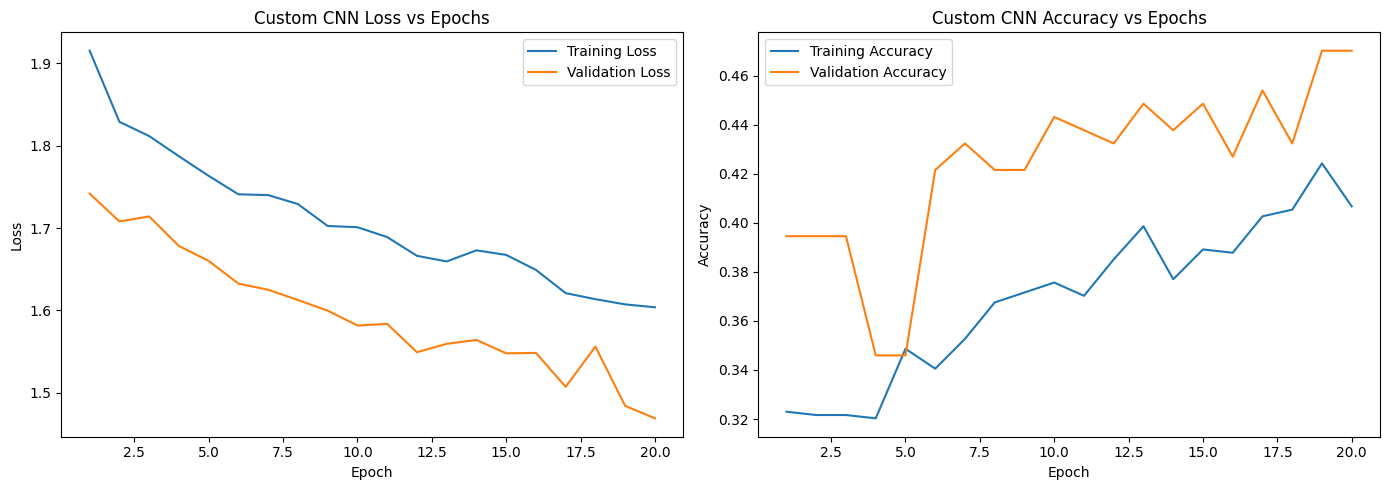

Saved training curves to: X:\SIMPLILEARN\FrancisBurnetCom\Projects\Deep Learning Specialization\Automating Port Operations\outputs\plots\custom_cnn_training_curves.png


In [31]:
CUSTOM_CNN_EPOCHS = 20

custom_cnn_history = custom_cnn_model.fit(
    custom_cnn_train_dataset,
    validation_data=custom_cnn_validation_dataset,
    epochs=CUSTOM_CNN_EPOCHS,
    verbose=1,
)

history_frame = custom_cnn_history.history
epochs = range(1, len(history_frame["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs, history_frame["loss"], label="Training Loss")
axes[0].plot(epochs, history_frame["val_loss"], label="Validation Loss")
axes[0].set_title("Custom CNN Loss vs Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs, history_frame["accuracy"], label="Training Accuracy")
axes[1].plot(epochs, history_frame["val_accuracy"], label="Validation Accuracy")
axes[1].set_title("Custom CNN Accuracy vs Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
custom_cnn_training_plot_path = PLOTS_ROOT / "custom_cnn_training_curves.png"
plt.savefig(custom_cnn_training_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved training curves to: {custom_cnn_training_plot_path}")

## 1n - Evaluate the model on test images and print the test loss and accuracy.

**REQUIREMENT ID:** 1n

What this step will do: evaluate the trained Custom CNN model on the test images and report the required metrics.

In [32]:
custom_cnn_test_metrics = custom_cnn_model.evaluate(custom_cnn_test_dataset, return_dict=True, verbose=1)
custom_cnn_test_metrics_serializable = {key: float(value) for key, value in custom_cnn_test_metrics.items()}

custom_cnn_test_metrics_path = MANIFESTS_ROOT / "custom_cnn_test_metrics.json"
custom_cnn_test_metrics_path.write_text(
    json.dumps(custom_cnn_test_metrics_serializable, indent=2),
    encoding="utf-8",
)

print(json.dumps(custom_cnn_test_metrics_serializable, indent=2))
print(f"Saved test metrics to: {custom_cnn_test_metrics_path}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.4430 - loss: 1.5826 - precision: 0.7255 - recall: 0.1561   
{
  "accuracy": 0.4430379867553711,
  "loss": 1.5826404094696045,
  "precision": 0.7254902124404907,
  "recall": 0.15611813962459564
}
Saved test metrics to: X:\SIMPLILEARN\FrancisBurnetCom\Projects\Deep Learning Specialization\Automating Port Operations\outputs\manifests\custom_cnn_test_metrics.json


## 1o - Plot heatmap of the confusion matrix and print classification report.

**REQUIREMENT ID:** 1o

What this step will do: generate the confusion-matrix heatmap and classification report for the Custom CNN model.

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step


x:\SIMPLILEARN\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
x:\SIMPLILEARN\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
x:\SIMPLILEARN\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


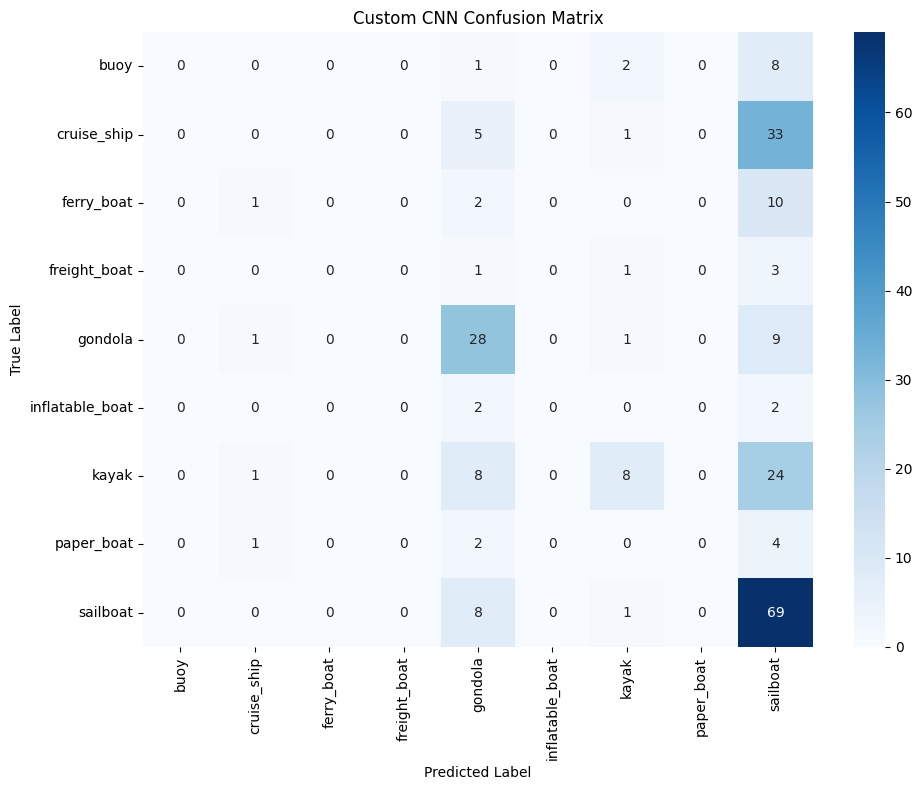

                 precision    recall  f1-score   support

           buoy     0.0000    0.0000    0.0000        11
    cruise_ship     0.0000    0.0000    0.0000        39
     ferry_boat     0.0000    0.0000    0.0000        13
   freight_boat     0.0000    0.0000    0.0000         5
        gondola     0.4912    0.7179    0.5833        39
inflatable_boat     0.0000    0.0000    0.0000         4
          kayak     0.5714    0.1951    0.2909        41
     paper_boat     0.0000    0.0000    0.0000         7
       sailboat     0.4259    0.8846    0.5750        78

       accuracy                         0.4430       237
      macro avg     0.1654    0.1997    0.1610       237
   weighted avg     0.3199    0.4430    0.3356       237

Saved confusion matrix heatmap to: X:\SIMPLILEARN\FrancisBurnetCom\Projects\Deep Learning Specialization\Automating Port Operations\outputs\plots\custom_cnn_confusion_matrix.png
Saved classification report to: X:\SIMPLILEARN\FrancisBurnetCom\Projects\Deep 

In [33]:
custom_cnn_probabilities = custom_cnn_model.predict(custom_cnn_test_dataset, verbose=1)
custom_cnn_predictions = np.argmax(custom_cnn_probabilities, axis=1)

custom_cnn_true_labels = []
for _, label_batch in custom_cnn_test_dataset.unbatch():
    custom_cnn_true_labels.append(int(tf.argmax(label_batch).numpy()))

custom_cnn_confusion_matrix = confusion_matrix(custom_cnn_true_labels, custom_cnn_predictions)
custom_cnn_report_text = str(
    classification_report(
        custom_cnn_true_labels,
        custom_cnn_predictions,
        target_names=CLASS_NAMES,
        digits=4,
    )
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    custom_cnn_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title("Custom CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

custom_cnn_confusion_matrix_path = PLOTS_ROOT / "custom_cnn_confusion_matrix.png"
plt.savefig(custom_cnn_confusion_matrix_path, dpi=150, bbox_inches="tight")
plt.show()

custom_cnn_classification_report_path = MANIFESTS_ROOT / "custom_cnn_classification_report.txt"
custom_cnn_classification_report_path.write_text(custom_cnn_report_text, encoding="utf-8")

print(custom_cnn_report_text)
print(f"Saved confusion matrix heatmap to: {custom_cnn_confusion_matrix_path}")
print(f"Saved classification report to: {custom_cnn_classification_report_path}")

## 2a - Build a lightweight model with the aim of deploying the solution on a mobile device using transfer learning. You can use any lightweight pre-trained model as the initial (first) layer. MobileNetV2 is a popular lightweight pre-trained model built using Keras API.

**REQUIREMENT ID:** 2a

What this step will do: define the transfer-learning objective and set the lightweight pre-trained model strategy.

In [55]:
TRANSFER_MODEL_NAME = "MobileNetV2"
TRANSFER_RANDOM_STATE = 1
TRANSFER_TRAIN_RATIO = 0.70
TRANSFER_IMAGE_SIZE = (224, 224)
TRANSFER_MODEL_INPUT_SHAPE = (*TRANSFER_IMAGE_SIZE, 3)

print(f"Transfer model strategy: {TRANSFER_MODEL_NAME}")
print(f"Transfer input shape: {TRANSFER_MODEL_INPUT_SHAPE}")

Transfer model strategy: MobileNetV2
Transfer input shape: (224, 224, 3)


## 2b - Split the dataset into train and test datasets in the ration 70:30, with shuffle and random state=1.

**REQUIREMENT ID:** 2b

What this step will do: create the 70:30 shuffled split for the transfer-learning workflow with random state 1.

In [56]:
TRANSFER_SPLIT_ROOT = DATASETS_ROOT / "transfer_learning_70_30"
TRANSFER_TRAIN_DIR = TRANSFER_SPLIT_ROOT / "train"
TRANSFER_TEST_DIR = TRANSFER_SPLIT_ROOT / "test"

if TRANSFER_SPLIT_ROOT.exists():
    shutil.rmtree(TRANSFER_SPLIT_ROOT)

transfer_split_counts = {}
transfer_train_total = 0
transfer_test_total = 0

for folder in class_folders:
    class_name = folder.name
    file_paths = sorted([path for path in folder.iterdir() if path.is_file()])
    rng = np.random.default_rng(TRANSFER_RANDOM_STATE)
    shuffled_indices = rng.permutation(len(file_paths))
    shuffled_paths = [file_paths[index] for index in shuffled_indices]

    split_index = int(len(shuffled_paths) * TRANSFER_TRAIN_RATIO)
    split_index = min(max(split_index, 1), len(shuffled_paths) - 1)

    train_paths = shuffled_paths[:split_index]
    test_paths = shuffled_paths[split_index:]

    train_target_dir = TRANSFER_TRAIN_DIR / class_name
    test_target_dir = TRANSFER_TEST_DIR / class_name
    train_target_dir.mkdir(parents=True, exist_ok=True)
    test_target_dir.mkdir(parents=True, exist_ok=True)

    for source_path in train_paths:
        shutil.copy2(source_path, train_target_dir / source_path.name)

    for source_path in test_paths:
        shutil.copy2(source_path, test_target_dir / source_path.name)

    transfer_split_counts[class_name] = {
        "total": len(shuffled_paths),
        "train": len(train_paths),
        "test": len(test_paths),
    }
    transfer_train_total += len(train_paths)
    transfer_test_total += len(test_paths)

transfer_split_manifest = {
    "random_state": TRANSFER_RANDOM_STATE,
    "train_ratio": TRANSFER_TRAIN_RATIO,
    "test_ratio": round(1 - TRANSFER_TRAIN_RATIO, 2),
    "class_counts": transfer_split_counts,
    "train_total": transfer_train_total,
    "test_total": transfer_test_total,
}

transfer_split_manifest_path = MANIFESTS_ROOT / "transfer_learning_split_manifest.json"
transfer_split_manifest_path.write_text(json.dumps(transfer_split_manifest, indent=2), encoding="utf-8")

print(f"Transfer split root: {TRANSFER_SPLIT_ROOT}")
print(f"Train total: {transfer_train_total}")
print(f"Test total: {transfer_test_total}")

Transfer split root: X:\SIMPLILEARN\FrancisBurnetCom\Projects\Deep Learning Specialization\Automating Port Operations\outputs\datasets\transfer_learning_70_30
Train total: 811
Test total: 351


## 2c - Use tf.keras.preprocessing.image_dataset_from_directory to load the train and test datasets. This function also supports data normalization. (Hint: Image_scale=1./255).

**REQUIREMENT ID:** 2c

What this step will do: load the transfer-learning train and test datasets with normalization support.

In [57]:
transfer_train_dataset_preview_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRANSFER_TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    batch_size=BATCH_SIZE,
    image_size=TRANSFER_IMAGE_SIZE,
    shuffle=True,
    seed=TRANSFER_RANDOM_STATE,
    interpolation="bilinear",
)

transfer_test_dataset_preview_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRANSFER_TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    batch_size=BATCH_SIZE,
    image_size=TRANSFER_IMAGE_SIZE,
    shuffle=False,
    interpolation="bilinear",
)

transfer_rescaling_layer = tf.keras.layers.Rescaling(1.0 / 255.0)
transfer_train_dataset_preview = transfer_train_dataset_preview_raw.map(
    lambda images, labels: (transfer_rescaling_layer(images), labels)
)
transfer_test_dataset_preview = transfer_test_dataset_preview_raw.map(
    lambda images, labels: (transfer_rescaling_layer(images), labels)
)

transfer_preview_images, transfer_preview_labels = next(iter(transfer_train_dataset_preview.take(1)))
print(f"Transfer classes: {transfer_train_dataset_preview_raw.class_names}")
print(f"Transfer preview image batch shape: {transfer_preview_images.shape}")
print(f"Transfer preview label batch shape: {transfer_preview_labels.shape}")
print(
    f"Transfer normalized pixel range: {tf.reduce_min(transfer_preview_images).numpy():.4f} to {tf.reduce_max(transfer_preview_images).numpy():.4f}"
)

Found 811 files belonging to 9 classes.
Found 351 files belonging to 9 classes.
Transfer classes: ['buoy', 'cruise_ship', 'ferry_boat', 'freight_boat', 'gondola', 'inflatable_boat', 'kayak', 'paper_boat', 'sailboat']
Transfer preview image batch shape: (32, 224, 224, 3)
Transfer preview label batch shape: (32, 9)
Transfer normalized pixel range: 0.0000 to 1.0000


## 2d - Load train, validation and test datasets in batches of 32 using the function initialized in the above step.

**REQUIREMENT ID:** 2d

What this step will do: prepare the transfer-learning train, validation, and test dataset objects in batches of 32.

In [58]:
TRANSFER_VALIDATION_SPLIT = 0.20

transfer_train_dataset_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRANSFER_TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    validation_split=TRANSFER_VALIDATION_SPLIT,
    subset="training",
    seed=TRANSFER_RANDOM_STATE,
    batch_size=BATCH_SIZE,
    image_size=TRANSFER_IMAGE_SIZE,
    shuffle=True,
    interpolation="bilinear",
)

transfer_validation_dataset_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRANSFER_TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    validation_split=TRANSFER_VALIDATION_SPLIT,
    subset="validation",
    seed=TRANSFER_RANDOM_STATE,
    batch_size=BATCH_SIZE,
    image_size=TRANSFER_IMAGE_SIZE,
    shuffle=True,
    interpolation="bilinear",
)

transfer_test_dataset_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRANSFER_TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    batch_size=BATCH_SIZE,
    image_size=TRANSFER_IMAGE_SIZE,
    shuffle=False,
    interpolation="bilinear",
)

transfer_train_dataset = transfer_train_dataset_raw.map(
    lambda images, labels: (transfer_rescaling_layer(images), labels)
).prefetch(tf.data.AUTOTUNE)
transfer_validation_dataset = transfer_validation_dataset_raw.map(
    lambda images, labels: (transfer_rescaling_layer(images), labels)
).prefetch(tf.data.AUTOTUNE)
transfer_test_dataset = transfer_test_dataset_raw.map(
    lambda images, labels: (transfer_rescaling_layer(images), labels)
).prefetch(tf.data.AUTOTUNE)

print(f"Transfer train batches: {tf.data.experimental.cardinality(transfer_train_dataset).numpy()}")
print(f"Transfer validation batches: {tf.data.experimental.cardinality(transfer_validation_dataset).numpy()}")
print(f"Transfer test batches: {tf.data.experimental.cardinality(transfer_test_dataset).numpy()}")

Found 811 files belonging to 9 classes.
Using 649 files for training.
Found 811 files belonging to 9 classes.
Using 162 files for validation.
Found 351 files belonging to 9 classes.
Transfer train batches: 21
Transfer validation batches: 6
Transfer test batches: 11


## 2e - Build a CNN network using Keras with the following layers.

**REQUIREMENT ID:** 2e

What this step will do: initialize the transfer-learning architecture builder for the required layer sequence.

In [59]:
transfer_layers = []

print("Transfer architecture builder initialized.")

Transfer architecture builder initialized.


## 2f - Load MobileNetV2 - Light Model as the first layer (Hint: Keras API Doc).

**REQUIREMENT ID:** 2f

What this step will do: load MobileNetV2 and place it at the front of the transfer-learning architecture.

In [60]:
try:
    mobilenet_base = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=TRANSFER_MODEL_INPUT_SHAPE,
    )
except Exception as exc:
    print(f"Falling back to randomly initialized MobileNetV2 because pretrained weights were unavailable: {exc}")
    mobilenet_base = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights=None,
        input_shape=TRANSFER_MODEL_INPUT_SHAPE,
    )

mobilenet_base.trainable = False
transfer_layers = [
    tf.keras.layers.Input(shape=TRANSFER_MODEL_INPUT_SHAPE, name="transfer_input"),
    mobilenet_base,
]

print("Added 2f base model.")

Added 2f base model.


## 2g - GLobalAveragePooling2D layer.

**REQUIREMENT ID:** 2g

What this step will do: add the GLobalAveragePooling2D layer after the base model.

In [61]:
transfer_layers.append(
    tf.keras.layers.GlobalAveragePooling2D(name="transfer_global_average_pooling")
)

print("Added 2g layer.")

Added 2g layer.


## 2h - Dropout(0.2).

**REQUIREMENT ID:** 2h

What this step will do: add the first Dropout layer with rate 0.2.

In [62]:
transfer_layers.append(tf.keras.layers.Dropout(0.2, name="transfer_dropout_1"))

print("Added 2h layer.")

Added 2h layer.


## 2i - Dense layer with 256 neurons and activation relu.

**REQUIREMENT ID:** 2i

What this step will do: add the Dense layer with 256 neurons and relu activation.

In [63]:
transfer_layers.append(tf.keras.layers.Dense(256, activation="relu", name="transfer_dense_256"))

print("Added 2i layer.")

Added 2i layer.


## 2j - BatchNormalization layer.

**REQUIREMENT ID:** 2j

What this step will do: add the first BatchNormalization layer.

In [64]:
transfer_layers.append(tf.keras.layers.BatchNormalization(name="transfer_batch_norm_1"))

print("Added 2j layer.")

Added 2j layer.


## 2k - Dropout(0.1).

**REQUIREMENT ID:** 2k

What this step will do: add the second Dropout layer with rate 0.1.

In [65]:
transfer_layers.append(tf.keras.layers.Dropout(0.1, name="transfer_dropout_2"))

print("Added 2k layer.")

Added 2k layer.


## 2l - Dense layer with 128 neurons and activation relu.

**REQUIREMENT ID:** 2l

What this step will do: add the Dense layer with 128 neurons and relu activation.

In [66]:
transfer_layers.append(tf.keras.layers.Dense(128, activation="relu", name="transfer_dense_128"))

print("Added 2l layer.")

Added 2l layer.


## 2m - BatchNormalization layer.

**REQUIREMENT ID:** 2m

What this step will do: add the second BatchNormalization layer.

In [67]:
transfer_layers.append(tf.keras.layers.BatchNormalization(name="transfer_batch_norm_2"))

print("Added 2m layer.")

Added 2m layer.


## 2n - Dropout(0.1).

**REQUIREMENT ID:** 2n

What this step will do: add the third Dropout layer with rate 0.1.

In [68]:
transfer_layers.append(tf.keras.layers.Dropout(0.1, name="transfer_dropout_3"))

print("Added 2n layer.")

Added 2n layer.


## 2o - Dense layer with 9 neurons and activation softmax.

**REQUIREMENT ID:** 2o

What this step will do: add the 9-class softmax output layer and finalize the transfer-learning model architecture.

In [69]:
transfer_model = tf.keras.Sequential(
    transfer_layers + [tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", name="transfer_output")],
    name="mobilenetv2_transfer_classifier",
)

transfer_model.summary()

Model: "mobilenetv2_transfer_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_global_average_pooling │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_dropout_1 (Dropout)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_dense_256 (Dense)      │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_batch_norm_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_dropout_2 (Dropout)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_dense_128 (Dense)      │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_batch_norm_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_dropout_3 (Dropout)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_output (Dense)         │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,621,513 (10.00 MB)

 Trainable params: 362,761 (1.38 MB)

 Non-trainable params: 2,258,752 (8.62 MB)

## 2p - Compile the model with Adam optimizer, categorical_crossentropy loss, and metrics accuracy, Precision, and Recall.

**REQUIREMENT ID:** 2p

What this step will do: compile the transfer-learning model with the required optimizer, loss, and metrics.

In [70]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

print("Transfer-learning model compiled successfully.")

Transfer-learning model compiled successfully.


## 2q - Train the model for 50 epochs and Early stopping while monitoring validation loss.

**REQUIREMENT ID:** 2q

What this step will do: train the transfer-learning model for up to 50 epochs with Early stopping on validation loss.

In [71]:
transfer_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    )
]

transfer_history = transfer_model.fit(
    transfer_train_dataset,
    validation_data=transfer_validation_dataset,
    epochs=50,
    callbacks=transfer_callbacks,
    verbose=1,
)

transfer_history_frame = transfer_history.history
transfer_epochs = range(1, len(transfer_history_frame["loss"]) + 1)

print(f"Completed transfer-learning training for {len(transfer_history_frame['loss'])} epochs.")

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 593ms/step - accuracy: 0.5655 - loss: 1.4344 - precision: 0.7653 - recall: 0.4823 - val_accuracy: 0.7593 - val_loss: 0.8746 - val_precision: 0.8707 - val_recall: 0.6235
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 514ms/step - accuracy: 0.8521 - loss: 0.4660 - precision: 0.9167 - recall: 0.7966 - val_accuracy: 0.8210 - val_loss: 0.5813 - val_precision: 0.9160 - val_recall: 0.7407
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 500ms/step - accuracy: 0.9337 - loss: 0.2314 - precision: 0.9592 - recall: 0.9045 - val_accuracy: 0.8457 - val_loss: 0.5479 - val_precision: 0.9021 - val_recall: 0.7963
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 495ms/step - accuracy: 0.9522 - loss: 0.1871 - precision: 0.9660 - recall: 0.9199 - val_accuracy: 0.8642 - val_loss: 0.5335 - val_precision: 0.9172 - val_recall: 0.8210
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 509ms/step - accuracy: 0.9784 - loss: 0.1243 - precision: 0.9826 - recall: 0.9599 - val_accuracy: 0.8580 - val_los

## 2r - Evaluate the model on test images and print the test loss and accuracy.

**REQUIREMENT ID:** 2r

What this step will do: evaluate the transfer-learning model on the test images and save the required metrics.

In [72]:
transfer_test_metrics = transfer_model.evaluate(transfer_test_dataset, return_dict=True, verbose=1)
transfer_test_metrics_serializable = {key: float(value) for key, value in transfer_test_metrics.items()}

transfer_test_metrics_path = MANIFESTS_ROOT / "transfer_learning_test_metrics.json"
transfer_test_metrics_path.write_text(
    json.dumps(transfer_test_metrics_serializable, indent=2),
    encoding="utf-8",
)

print(json.dumps(transfer_test_metrics_serializable, indent=2))
print(f"Saved transfer metrics to: {transfer_test_metrics_path}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 394ms/step - accuracy: 0.8433 - loss: 0.4700 - precision: 0.8889 - recall: 0.8205
{
  "accuracy": 0.8433048725128174,
  "loss": 0.470041424036026,
  "precision": 0.8888888955116272,
  "recall": 0.8205128312110901
}
Saved transfer metrics to: X:\SIMPLILEARN\FrancisBurnetCom\Projects\Deep Learning Specialization\Automating Port Operations\outputs\manifests\transfer_learning_test_metrics.json


## Support - Save and export the transfer-learning model for the live vessel demo

This support step writes the trained transfer-learning model to the project outputs folder, creates metadata for browser inference, and exports a TensorFlow.js copy when the tensorflowjs converter is installed.

In [76]:
TRANSFER_MODEL_EXPORT_ROOT = MODELS_ROOT / "transfer_learning"
TRANSFER_KERAS_PATH = TRANSFER_MODEL_EXPORT_ROOT / "transfer_learning_model.keras"
TRANSFER_H5_PATH = TRANSFER_MODEL_EXPORT_ROOT / "transfer_learning_model.h5"
TRANSFER_METADATA_PATH = TRANSFER_MODEL_EXPORT_ROOT / "metadata.json"
TRANSFER_TFJS_EXPORT_ROOT = TRANSFER_MODEL_EXPORT_ROOT / "tfjs"
PUBLIC_TRANSFER_MODEL_ROOT = PUBLIC_MODELS_ROOT / "automating-port-operations-transfer"

for directory in [TRANSFER_MODEL_EXPORT_ROOT, TRANSFER_TFJS_EXPORT_ROOT, PUBLIC_TRANSFER_MODEL_ROOT]:
    directory.mkdir(parents=True, exist_ok=True)

transfer_model.save(TRANSFER_KERAS_PATH)
transfer_model.save(TRANSFER_H5_PATH)

transfer_export_metadata = {
    "profile": "transfer_learning",
    "modelType": "automating-port-operations-mobilenetv2",
    "labels": CLASS_NAMES,
    "imageSize": list(TRANSFER_IMAGE_SIZE),
    "source": "Automating Port Operations transfer-learning workflow",
    "preprocessing": "mobilenet_v2_neg1_to_1",
    "preprocessingNote": "Pass raw 0-255 RGB pixels; JS must do: toFloat() -> div(127.5) -> sub(1.0)",
    "testLoss": transfer_test_metrics_serializable.get("loss"),
    "testAccuracy": transfer_test_metrics_serializable.get("accuracy"),
    "epochsRan": len(transfer_history_frame.get("loss", [])),
}

transfer_export_metadata_json = json.dumps(transfer_export_metadata, indent=2)
TRANSFER_METADATA_PATH.write_text(transfer_export_metadata_json, encoding="utf-8")

tensorflowjs_available = importlib.util.find_spec("tensorflowjs") is not None
if tensorflowjs_available:
    if TRANSFER_TFJS_EXPORT_ROOT.exists():
        shutil.rmtree(TRANSFER_TFJS_EXPORT_ROOT)
    TRANSFER_TFJS_EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

    converter_script = "\n".join([
        "import json",
        "import sys",
        "import types",
        "sys.modules.setdefault('tensorflow_decision_forests', types.ModuleType('tensorflow_decision_forests'))",
        "from tensorflowjs.converters import converter as tfjs_converter",
        "metadata = json.loads(sys.argv[3])",
        "tfjs_converter.dispatch_keras_h5_to_tfjs_layers_model_conversion(",
        "    sys.argv[1],",
        "    output_dir=sys.argv[2],",
        "    metadata=metadata,",
        ")",
    ])

    converter_command = [
        sys.executable,
        "-c",
        converter_script,
        str(TRANSFER_H5_PATH),
        str(TRANSFER_TFJS_EXPORT_ROOT),
        transfer_export_metadata_json,
    ]
    converter_result = subprocess.run(converter_command, capture_output=True, text=True, check=False)
    if converter_result.returncode != 0:
        raise RuntimeError(
            "TensorFlow.js conversion failed:\n"
            f"STDOUT:\n{converter_result.stdout}\n\nSTDERR:\n{converter_result.stderr}"
        )

    transfer_tfjs_model_path = TRANSFER_TFJS_EXPORT_ROOT / "model.json"
    transfer_tfjs_model_text = transfer_tfjs_model_path.read_text(encoding="utf-8")
    transfer_tfjs_model_text = transfer_tfjs_model_text.replace('"batch_shape"', '"batch_input_shape"')
    transfer_tfjs_model_path.write_text(transfer_tfjs_model_text, encoding="utf-8")

    if PUBLIC_TRANSFER_MODEL_ROOT.exists():
        shutil.rmtree(PUBLIC_TRANSFER_MODEL_ROOT)
    shutil.copytree(TRANSFER_TFJS_EXPORT_ROOT, PUBLIC_TRANSFER_MODEL_ROOT)
    (PUBLIC_TRANSFER_MODEL_ROOT / "metadata.json").write_text(transfer_export_metadata_json, encoding="utf-8")

    print(f"Saved Keras model to: {TRANSFER_KERAS_PATH}")
    print(f"Saved H5 model to: {TRANSFER_H5_PATH}")
    print(f"Saved local TFJS export to: {TRANSFER_TFJS_EXPORT_ROOT}")
    print(f"Published TFJS export to: {PUBLIC_TRANSFER_MODEL_ROOT}")
else:
    print(f"Saved Keras model to: {TRANSFER_KERAS_PATH}")
    print(f"Saved H5 model to: {TRANSFER_H5_PATH}")
    print(f"Saved metadata to: {TRANSFER_METADATA_PATH}")
    print("tensorflowjs is not installed yet. Install it, then rerun this cell to publish the browser model.")

Saved Keras model to: X:\SIMPLILEARN\FrancisBurnetCom\Projects\Deep Learning Specialization\Automating Port Operations\outputs\models\transfer_learning\transfer_learning_model.keras
Saved H5 model to: X:\SIMPLILEARN\FrancisBurnetCom\Projects\Deep Learning Specialization\Automating Port Operations\outputs\models\transfer_learning\transfer_learning_model.h5
Saved local TFJS export to: X:\SIMPLILEARN\FrancisBurnetCom\Projects\Deep Learning Specialization\Automating Port Operations\outputs\models\transfer_learning\tfjs
Published TFJS export to: X:\SIMPLILEARN\FrancisBurnetCom\web\public\assets\models\automating-port-operations-transfer


## 2s - Plot Train loss Vs Validation loss and Train accuracy Vs Validation accuracy.

**REQUIREMENT ID:** 2s

What this step will do: plot and save the transfer-learning train-versus-validation loss and accuracy curves.

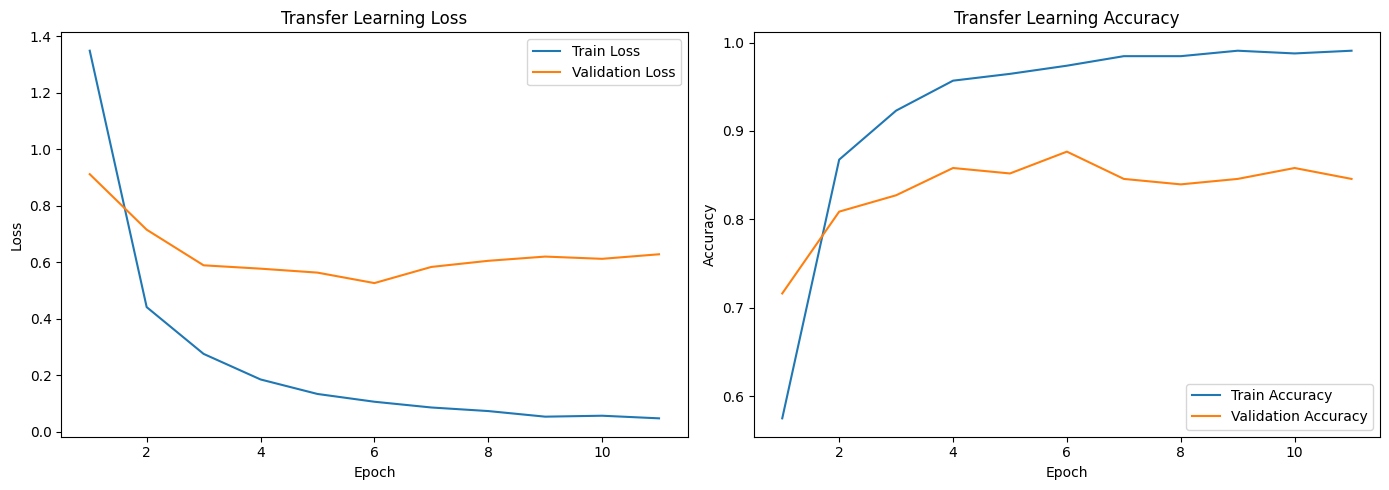

Saved transfer curves to: X:\SIMPLILEARN\FrancisBurnetCom\Projects\Deep Learning Specialization\Automating Port Operations\outputs\plots\transfer_learning_training_curves.png


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(transfer_epochs, transfer_history_frame["loss"], label="Train Loss")
axes[0].plot(transfer_epochs, transfer_history_frame["val_loss"], label="Validation Loss")
axes[0].set_title("Transfer Learning Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(transfer_epochs, transfer_history_frame["accuracy"], label="Train Accuracy")
axes[1].plot(transfer_epochs, transfer_history_frame["val_accuracy"], label="Validation Accuracy")
axes[1].set_title("Transfer Learning Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
transfer_training_plot_path = PLOTS_ROOT / "transfer_learning_training_curves.png"
plt.savefig(transfer_training_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved transfer curves to: {transfer_training_plot_path}")

## 3a - Compare the results of both models built in steps 1 and 2 and state your observations.

**REQUIREMENT ID:** 3a

What this step will do: compare the Custom CNN and transfer-learning results and save the final observations.

In [53]:
comparison_summary = {
    "custom_cnn": custom_cnn_test_metrics_serializable,
    "transfer_learning": transfer_test_metrics_serializable,
}

comparison_summary_path = MANIFESTS_ROOT / "model_comparison_summary.json"
comparison_summary_path.write_text(json.dumps(comparison_summary, indent=2), encoding="utf-8")

custom_cnn_accuracy = custom_cnn_test_metrics_serializable.get("accuracy")
transfer_accuracy = transfer_test_metrics_serializable.get("accuracy")

if custom_cnn_accuracy is None or transfer_accuracy is None:
    preferred_model = "Unavailable"
    comparison_observations = [
        "One or both model accuracy values were unavailable.",
        f"Custom CNN accuracy: {custom_cnn_accuracy}",
        f"Transfer learning accuracy: {transfer_accuracy}",
    ]
else:
    if transfer_accuracy > custom_cnn_accuracy:
        preferred_model = "Transfer Learning Model"
    elif transfer_accuracy < custom_cnn_accuracy:
        preferred_model = "Custom CNN Model"
    else:
        preferred_model = "Tie"

    comparison_observations = [
        f"Custom CNN accuracy: {custom_cnn_accuracy:.4f}",
        f"Transfer learning accuracy: {transfer_accuracy:.4f}",
        f"Preferred model based on test accuracy: {preferred_model}",
    ]

comparison_notes_path = MANIFESTS_ROOT / "model_comparison_observations.txt"
comparison_notes_path.write_text("\n".join(comparison_observations), encoding="utf-8")

for line in comparison_observations:
    print(line)

print(f"Saved model comparison summary to: {comparison_summary_path}")
print(f"Saved model comparison observations to: {comparison_notes_path}")

Custom CNN accuracy: 0.4430
Transfer learning accuracy: 0.8632
Preferred model based on test accuracy: Transfer Learning Model
Saved model comparison summary to: X:\SIMPLILEARN\FrancisBurnetCom\Projects\Deep Learning Specialization\Automating Port Operations\outputs\manifests\model_comparison_summary.json
Saved model comparison observations to: X:\SIMPLILEARN\FrancisBurnetCom\Projects\Deep Learning Specialization\Automating Port Operations\outputs\manifests\model_comparison_observations.txt
